In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
# get data 80

In [22]:
import os
import shutil
from att_tools import update_risk_by_ref
from data_vis.yolo_sta import yolo_sta
from yolo_tools import copy_dir, copy_all, copy_split, data_tf_pipline_new, copy_ref_csv
from yolo_mask_crop import myolo_crop

In [23]:
base_dir = r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030'
image_dir = os.path.join(base_dir, 'images')
label_ana_dir = os.path.join(base_dir, 'labels_analysis')
attribute_file = os.path.join(base_dir, 'attribute.yaml')
class_file = os.path.join(base_dir, 'class.txt')
class_c6_path = r'/localnvme/data/billboard/class_c6.txt'
class_c5_path = r'/localnvme/data/billboard/class_c5.txt'
att_l3_path = r'/localnvme/data/billboard/attribute.yaml'
att_l2_path = r'/localnvme/data/billboard/attribute_l2.yaml'
input_dir = base_dir
input_train_test_path = os.path.join(input_dir, 'train_test.txt')
input_val_test_path = os.path.join(input_dir, 'val_test.txt')
input_train_80p_path = os.path.join(input_dir, 'train_80p_ref.txt')
input_val_80p_path = os.path.join(input_dir, 'val_80p_ref.txt')
input_all_path = os.path.join(input_dir, 'all.txt')
input_all_test_path = os.path.join(input_dir, 'all_test.txt')
label_v19_dir = os.path.join(base_dir, 'labels_v19')
label_v18_dir = os.path.join(base_dir, 'labels_v18')
label_v19_sta_dir = os.path.join(label_ana_dir, 'labels_v19_sta')
label_v18_sta_dir = os.path.join(label_ana_dir, 'labels_v18_sta')
datav19_dir =  r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1117_v19'
datav19_dir_image = os.path.join(datav19_dir, 'images')
datav19_dir_label = os.path.join(datav19_dir, 'labels')
datav19_dir_label_crop = os.path.join(datav19_dir, 'labels_analysis', 'labels_crop')
syn_data_dir = r'/scrinvme/huilin/isds/check_data/synthetic_data_add1_v1'
syn_data_dir_image = os.path.join(syn_data_dir, 'images')
syn_data_dir_label = os.path.join(syn_data_dir, 'labels')

In [5]:
copy_dir(syn_data_dir_image, image_dir)

copy_dir: 100%|██████████| 58/58 [00:01<00:00, 53.40it/s]


In [7]:
os.makedirs(label_v19_dir, exist_ok=True)
copy_dir(label_v18_dir, label_v19_dir)
copy_dir(syn_data_dir_label, label_v19_dir)

copy_dir: 100%|██████████| 57/57 [00:00<00:00, 104.57it/s]


label read: 100%|██████████| 7954/7954 [00:34<00:00, 228.93it/s]


get 7954 labels, merging...


/localnvme/project/dataset_tools/data_vis/yolo_sta.py:303: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfs = pd.concat(dfs)


merging finish, get 61882 labels!
csv save to /localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030/labels_analysis/labels_v18_sta/sta_attribute.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
总box数: 61882; 有缺陷的box数: 4389; 没有缺陷的box数: 57493
总image数: 7848; 有缺陷的image数: 2963; 没有缺陷的image数: 4885
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
category        wall display  projecting frame  projecting display  \
deformation                9                 7                 159   
broken                   171                 1                  61   
abandonment              929                29                 174   
corrosion                127              1096                1319   
attribute sum           1197              1113                1628   
with attribute          1197              1113                1628   

category        hanging frame  hanging display  o

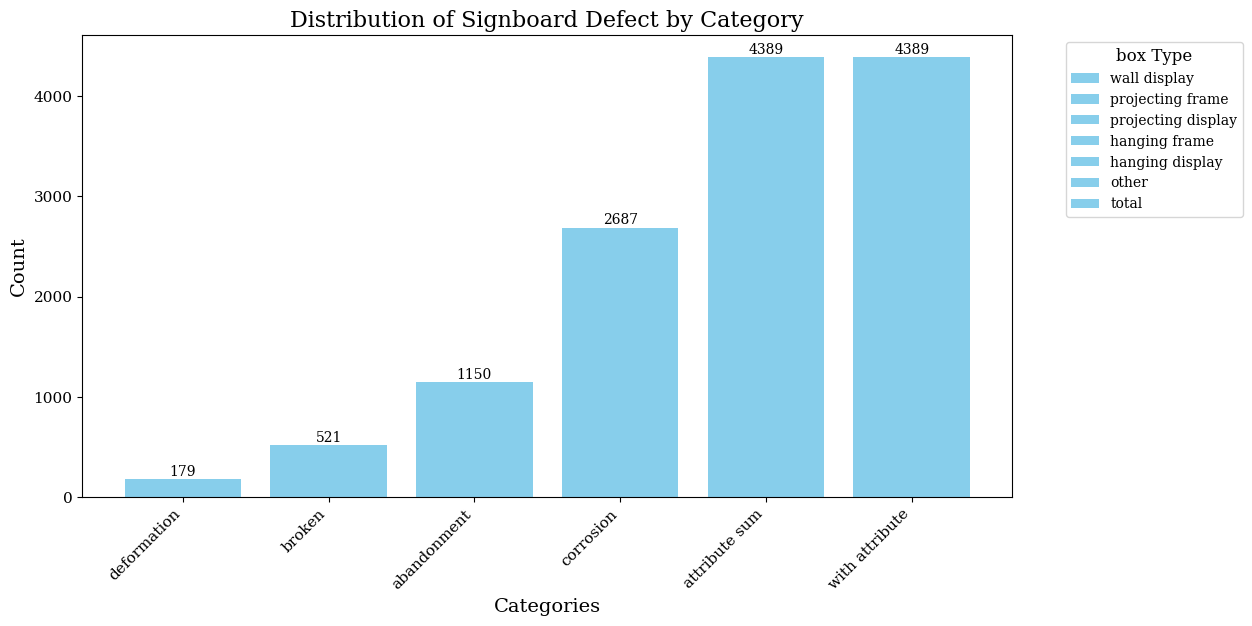

In [8]:
yolo_sta(
    gt_dir=label_v18_dir,
    result_dir=label_v18_sta_dir,
    class_path=class_file,
    attribute_path=attribute_file,
    seg=True,
)

label read: 100%|██████████| 8011/8011 [00:35<00:00, 225.14it/s]


get 8011 labels, merging...


/localnvme/project/dataset_tools/data_vis/yolo_sta.py:303: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfs = pd.concat(dfs)


merging finish, get 62506 labels!
csv save to /localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030/labels_analysis/labels_v19_sta/sta_attribute.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
总box数: 62506; 有缺陷的box数: 4480; 没有缺陷的box数: 58026
总image数: 7905; 有缺陷的image数: 3020; 没有缺陷的image数: 4885
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
category        wall display  projecting frame  projecting display  \
deformation                9                 7                 160   
broken                   202                 1                  77   
abandonment              935                29                 174   
corrosion                130              1102                1332   
attribute sum           1235              1119                1658   
with attribute          1235              1119                1658   

category        hanging frame  hanging display  o

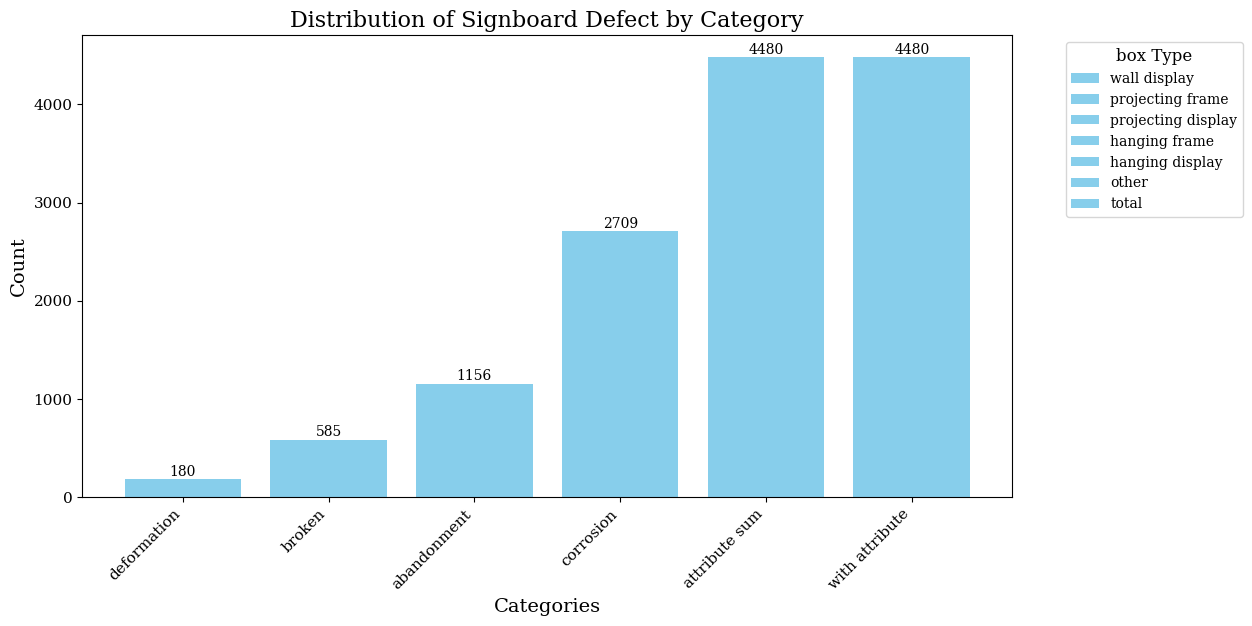

In [9]:
yolo_sta(
    gt_dir=label_v19_dir,
    result_dir=label_v19_sta_dir,
    class_path=class_file,
    attribute_path=attribute_file,
    seg=True,
)

In [ ]:
# get data18

In [10]:
copy_all(
    label_v19_dir,
    datav19_dir_label,
    image_dir,
    datav19_dir_image,
)

copy_all: 100%|██████████| 8011/8011 [00:10<00:00, 770.09it/s]


In [11]:
output_dir = datav19_dir
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_val_test_broken_path = os.path.join(output_dir, 'val_test_broken.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path)
copy_split(input_val_test_path, output_val_test_path)
copy_split(input_train_80p_path, output_train_80p_path)
copy_split(input_val_80p_path, output_val_80p_path)
copy_split(input_all_path, output_all_path)
copy_split(input_all_test_path, output_all_test_path)

shutil.copy(class_c6_path, os.path.join(output_dir, 'class.txt'))
shutil.copy(att_l3_path, os.path.join(output_dir, 'attribute.yaml'))

copy train_test.txt, 7872 records
copy val_test.txt, 80 records
copy train_80p_ref.txt, 7606 records
copy val_80p_ref.txt, 266 records
copy all.txt, 7872 records
copy all_test.txt, 7952 records


'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1117_v19/attribute.yaml'

In [12]:
data_tf_pipline_new(datav19_dir, copy_list=['mseg_c5_l2'])

risk to l2: 100%|██████████| 8011/8011 [00:12<00:00, 628.67it/s]


In [13]:
output_dir = datav19_dir.replace('mseg_c6', 'mseg_c5_l2')
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path, abs_path=True)
copy_split(input_val_test_path, output_val_test_path, abs_path=True)
copy_split(input_train_80p_path, output_train_80p_path, abs_path=True)
copy_split(input_val_80p_path, output_val_80p_path, abs_path=True)
copy_split(input_all_path, output_all_path, abs_path=True)
copy_split(input_all_test_path, output_all_test_path, abs_path=True)

copy train_test.txt, 7872 records
copy val_test.txt, 80 records
copy train_80p_ref.txt, 7606 records
copy val_80p_ref.txt, 266 records
copy all.txt, 7872 records
copy all_test.txt, 7952 records


In [19]:
myolo_crop(
    datav19_dir_image,
    datav19_dir_label,
    datav19_dir_label_crop,
    class_c6_path,
    attribute_file=att_l3_path,
    seg=True,
    annotation=False,
    save_method='attribute',
    only_defect=True,
    with_boundary=False,
    crop_method='with_background_box_shape'
)

100%|██████████| 62505/62505 [00:00<00:00, 399041.95it/s]


In [ ]:
# get data80

In [29]:
data80_dir = r'/localnvme/data/billboard/all_data/mseg_c5_l2/data80_v19'
class_c5_path = r'/localnvme/data/billboard/class_c5.txt'
att_l2_path = r'/localnvme/data/billboard/attribute_l2.yaml'

data7961_dir_mseg_c5_l2 = datav19_dir.replace('mseg_c6', 'mseg_c5_l2')
input_image_dir = os.path.join(data7961_dir_mseg_c5_l2, 'images')
input_label_dir = os.path.join(data7961_dir_mseg_c5_l2, 'labels')
# input_val_test_path = os.path.join(data7961_dir_mseg_c5_l2, 'val_test_broken.txt')
input_val_test_path = r'/localnvme/data/billboard/all_data/mseg_c5_l2/data7961_mseg_c5_l2_1117_v19_single_risk/b/val_test_broken_syn_v1.txt'

data80_image_dir = os.path.join(data80_dir, 'images')
data80_label_dir = os.path.join(data80_dir, 'labels')
data80_label_analysis_dir = os.path.join(data80_dir, 'labels_analysis')
data80_label_crop_dir = os.path.join(data80_dir, 'labels_crop')
data80_class_path = os.path.join(data80_dir, 'class.txt')
data80_att_path = os.path.join(data80_dir, 'attribute.yaml')

In [30]:
copy_ref_csv(input_image_dir, data80_image_dir, input_val_test_path)

100%|██████████| 88/88 [00:00<00:00, 325.44it/s]


In [31]:
copy_ref_csv(input_label_dir, data80_label_dir, input_val_test_path)

100%|██████████| 88/88 [00:00<00:00, 3354.44it/s]


In [32]:
shutil.copy(class_c5_path, data80_class_path)
shutil.copy(att_l2_path, data80_att_path)

'/localnvme/data/billboard/all_data/mseg_c5_l2/data80_v19/attribute.yaml'

In [33]:
myolo_crop(
    data80_image_dir,
    data80_label_dir,
    data80_label_crop_dir,
    class_c5_path,
    attribute_file=att_l2_path,
    seg=True,
    annotation=False,
    save_method='attribute',
    only_defect=True,
    with_boundary=False,
    crop_method='with_background_box_shape'
)

100%|██████████| 812/812 [00:00<00:00, 280958.16it/s]
